# 12. What is the average number of games per set in men's matches compared to women's matches?

### It imports two libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### Both `score_ready` and `set_scores_valid` must be `True`, because this question depends on the set scores themselves, and we need to ensure there are no impossible sets in the match.

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f"{IN_DIR}/event.parquet")

ev_ok = event.loc[event['score_ready'] & event['set_scores_valid']].copy()
print(f"Matches passing quality gate: {len(ev_ok)} / {len(event)} "
      f"({100*len(ev_ok)/len(event):.1f}%)")

Matches passing quality gate: 12923 / 16873 (76.6%)


#### It reads the three-set scores of each match (for home and away) and the gender of both players

In [3]:
home_s = pd.read_parquet(f"{IN_DIR}/home_team_score.parquet")[["match_id", "period_1", "period_2", "period_3"]]
away_s = pd.read_parquet(f"{IN_DIR}/away_team_score.parquet")[["match_id", "period_1", "period_2", "period_3"]]
home_g = pd.read_parquet(f"{IN_DIR}/home_team.parquet")[["match_id", "gender"]].rename(columns={"gender": "home_gender"})
away_g = pd.read_parquet(f"{IN_DIR}/away_team.parquet")[["match_id", "gender"]].rename(columns={"gender": "away_gender"})

#### It joins the home and away scores, then filters the results to include only valid matches (ev_ok) and adds the gender of both players

In [4]:
scores = home_s.merge(away_s, on="match_id", suffixes=("_home", "_away"))

merged = (
    ev_ok[["match_id"]]
    .merge(scores, on="match_id", how="inner")
    .merge(home_g, on="match_id", how="inner")
    .merge(away_g, on="match_id", how="inner")
)
print("Rows after quality-gated merge:", len(merged))

Rows after quality-gated merge: 8272


#### For each of the three sets, only the rows containing both values (home and away) are retained and stored as a single
#### independent row (representing one set); all the sets are then concatenated vertically
#### and the 'games' column (representing the total number of games in that set) is created

In [5]:
rows = []
for i in [1, 2, 3]:
    h = merged[f"period_{i}_home"]
    a = merged[f"period_{i}_away"]
    valid = h.notna() & a.notna()
    rows.append(pd.DataFrame({
        "home_games": h[valid],
        "away_games": a[valid],
        "gender": merged.loc[valid, "home_gender"],
    }))

sets_long = pd.concat(rows, ignore_index=True).dropna(subset=["gender"])
sets_long["games"] = sets_long["home_games"] + sets_long["away_games"]

#### Sets that did not conclude properly (such as a retirement mid-set) are identified and removed using the `is_complete` function

In [6]:
def is_complete(row):
    hi, lo = max(row["home_games"], row["away_games"]), min(row["home_games"], row["away_games"])
    return (hi == 7 and lo in (5, 6)) or (hi >= 6 and hi - lo >= 2)

clean = sets_long[sets_long.apply(is_complete, axis=1)]
print(f"Sets kept: {len(clean)} / {len(sets_long)} "
      f"({len(sets_long)-len(clean)} incomplete sets dropped)")

Sets kept: 18726 / 19042 (316 incomplete sets dropped)


#### Descriptive statistics for each group are printed

In [7]:
print(clean.groupby("gender")["games"].describe())

F = clean.loc[clean["gender"] == "F", "games"]
M = clean.loc[clean["gender"] == "M", "games"]
means = [F.mean(), M.mean()]

print(f"Mean F = {means[0]:.3f}, Mean M = {means[1]:.3f}")

          count      mean       std  min  25%  50%   75%   max
gender                                                        
F        8257.0  9.274676  2.163469  6.0  8.0  9.0  10.0  26.0
M       10469.0  9.647817  2.193943  6.0  8.0  9.0  10.0  40.0
Mean F = 9.275, Mean M = 9.648


#### The bar chart plots the average number of games per set for the two groups

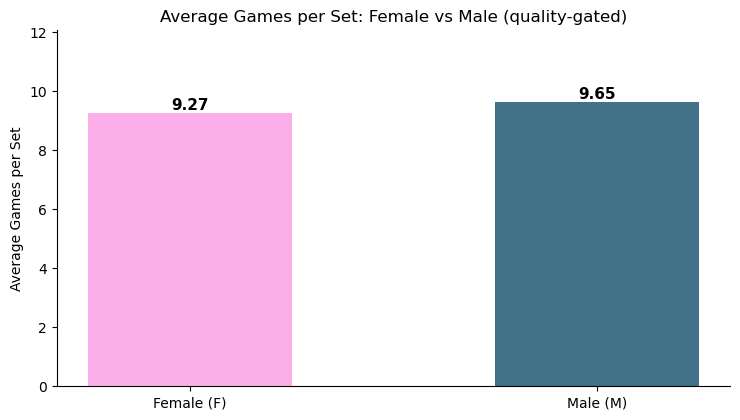

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(["Female (F)", "Male (M)"], means, color=["#FBA0E3", "#1F5973"], alpha=0.85, width=0.5)
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Average Games per Set: Female vs Male (quality-gated)")
ax.set_ylabel("Average Games per Set")
ax.set_ylim(0, max(means) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/q12_games_per_set.png", dpi=170)
plt.show()

The average number of games per set is 9.65 for men and 9.27 for women, indicating a difference of approximately half a game.

Observing the median—which is 9 for both groups—reveals that the discrepancy lies in longer sets and tie-breaks.

This slight difference may stem from the fact that women play best-of-three sets while men play best-of-five, or it could result from the differing scoring structures in men's five-set matches or the greater competitiveness of men's matches, rather than reflecting a difference in performance.

(Prior to calculation, 617 incomplete sets—such as 0-0 or 3-2 scores resulting from retirements or walkovers rather than a natural conclusion—were identified and excluded from the total of 20,461 sets to prevent the average from being artificially skewed downward.)